In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from collections import Counter


# Load numerical dataset
numerical_data  = pd.read_csv('numerical_customer_data.csv', index_col=0)

# Load categorical dataset
categorical_data = pd.read_csv('categorical_customer_data.csv', index_col=0)

# Verify the datasets
print(f"Numerical Dataset Shape: {numerical_data.shape}")
print(f"Categorical Dataset Shape: {categorical_data.shape}")

Numerical Dataset Shape: (3607, 10)
Categorical Dataset Shape: (3607, 3)


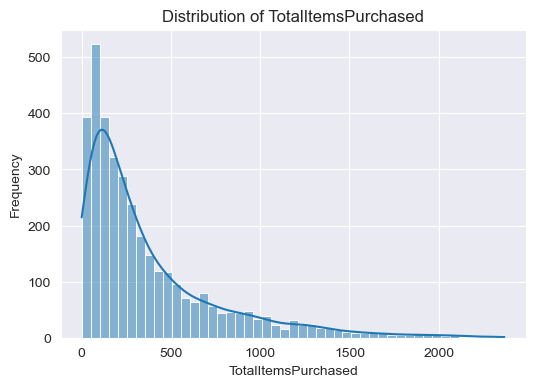

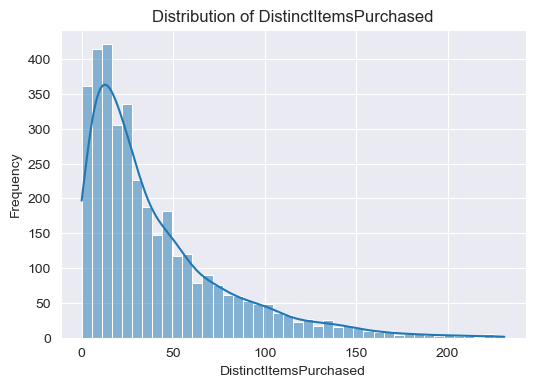

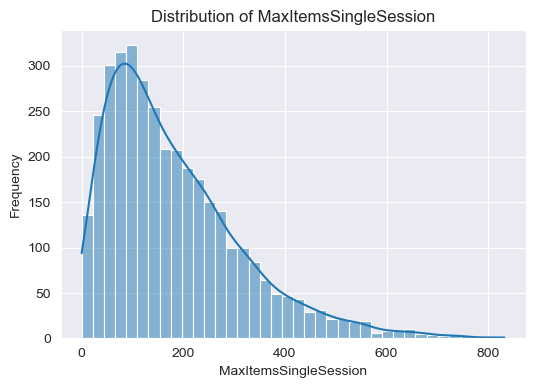

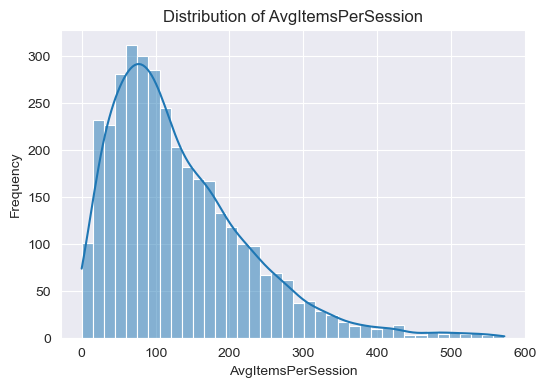

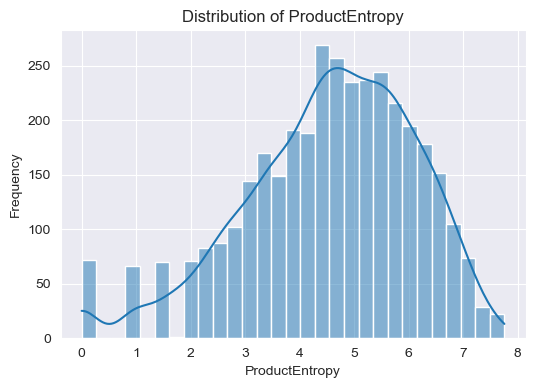

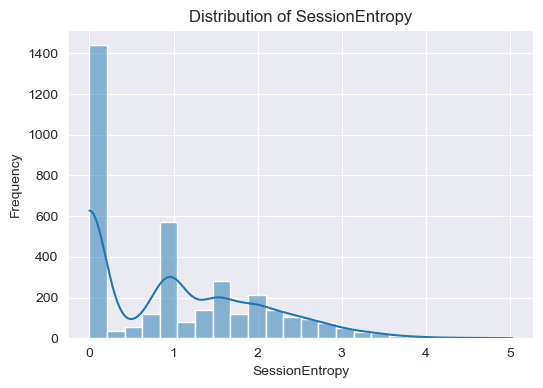

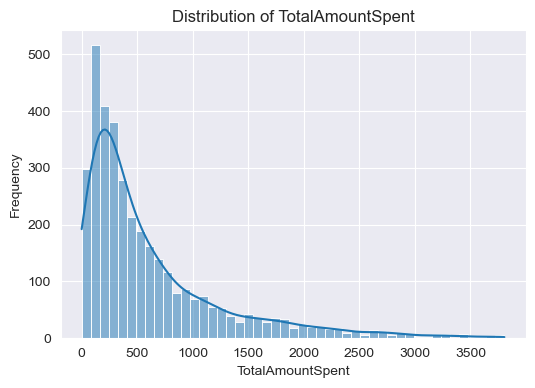

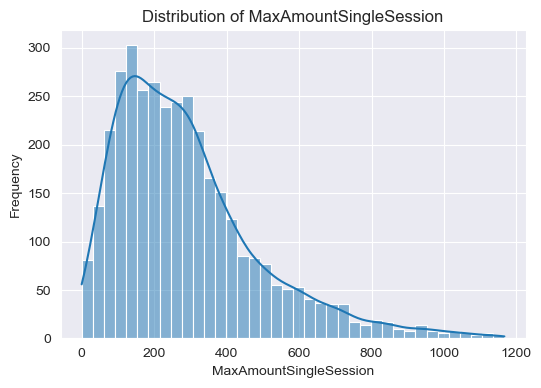

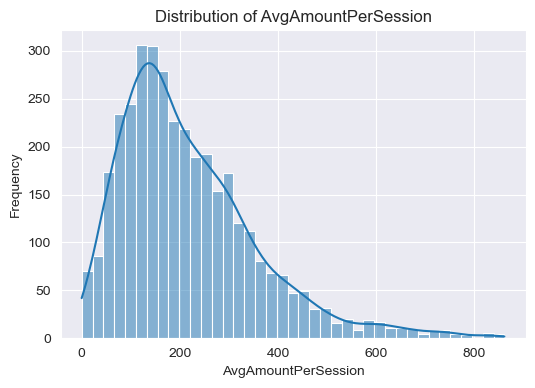

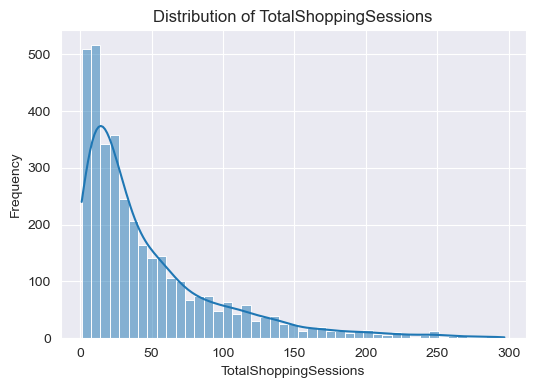

In [2]:
numerical_features = numerical_data  
# Plot histograms for Gaussian distribution assessment
for column in numerical_features.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(numerical_features[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

### **Effects of Log Transformation**
1. **Changes Scale**:
   - Log transformation compresses the range of large values, reducing the impact of extreme outliers.

### **Is it Necessary?**
Log transformation is recommended when:
- Features are highly skewed and need normalization for distance-based or variance-sensitive methods.
- The structure of the data (e.g., clustering results) improves after transformation.

---

### **Trade-Offs**
- **Pros**:
  - Reduces skewness.
  - Helps algorithms perform better when working with skewed data.
- **Cons**:
  - Alters the original data scale, which might complicate interpretation.
  - Requires all values to be positive or slightly adjusted (e.g., `log(1 + x)`).


- since our primary goal is clustering with **K-means** or reducing dimensions with **PCA**, applying a log transformation to highly skewed features is a good choice.


In [3]:
skewness = numerical_data.skew()
print("Skewness of Features:")
print(skewness)

Skewness of Features:
TotalItemsPurchased       1.900305
DistinctItemsPurchased    1.674611
MaxItemsSingleSession     1.250572
AvgItemsPerSession        1.345675
ProductEntropy           -0.608359
SessionEntropy            0.707832
TotalAmountSpent          1.924602
MaxAmountSingleSession    1.298584
AvgAmountPerSession       1.270625
TotalShoppingSessions     1.882902
dtype: float64


### **1. Highly Skewed Features** (Skewness > 1.5)
- **Features**: 
  - `TotalItemsPurchased` (1.90)
  - `DistinctItemsPurchased` (1.67)
  - `TotalAmountSpent` (1.92)
  - `TotalShoppingSessions` (1.88)



### **2. Moderately Skewed Features** (1.0 < Skewness ≤ 1.5)
- **Features**:
  - `MaxItemsSingleSession` (1.25)
  - `AvgItemsPerSession` (1.35)
  - `MaxAmountSingleSession` (1.29)
  - `AvgAmountPerSession` (1.27)

- **Reason**:
  - These features have moderate skewness. While log transformation may improve symmetry, it is less critical compared to highly skewed features.
  - Applying transformation here can make the data more comparable across features.

---

### **3. Symmetric or Slightly Skewed Features** (Skewness ≤ 1)
- **Features**:
  - `ProductEntropy` (-0.61)
  - `SessionEntropy` (0.71)

- **Reason**:
  - These features are already close to normal or symmetric, and applying a log transformation is unnecessary.
  - Transforming such features might introduce noise rather than improving the data.

In [4]:
# Apply log transformation to skewed features
skewed_features = [
    "TotalItemsPurchased",
    "DistinctItemsPurchased",
    "MaxItemsSingleSession",
    "AvgItemsPerSession",
    "TotalAmountSpent",
    "MaxAmountSingleSession",
    "AvgAmountPerSession",
    "TotalShoppingSessions",
]

# Make a copy of the original data
log_transformed_data = numerical_data.copy()

# Apply log transformation to skewed features
for feature in skewed_features:
    if log_transformed_data[feature].min() <= 0:
        # Shift data to make all values positive
        shift = abs(log_transformed_data[feature].min()) + 1
        log_transformed_data[feature] += shift
    log_transformed_data[feature] = np.log1p(log_transformed_data[feature])

In [5]:
# Standardize the data
scaler = StandardScaler()
standardized_data = scaler.fit_transform(log_transformed_data)

# Convert back to a DataFrame for easier handling
standardized_data = pd.DataFrame(standardized_data, columns=numerical_data.columns)


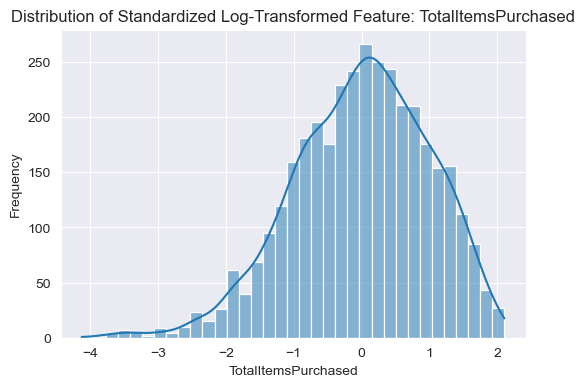

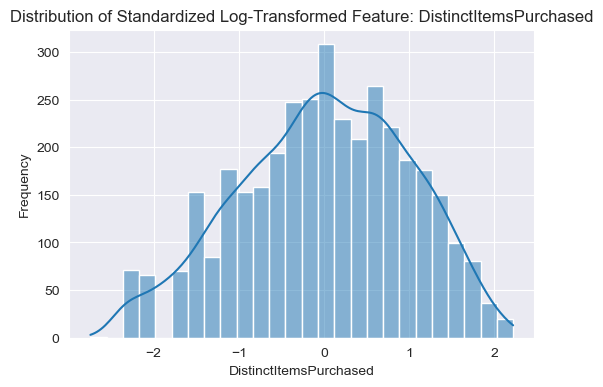

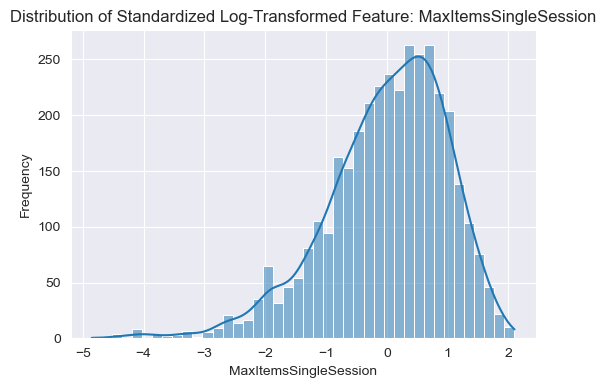

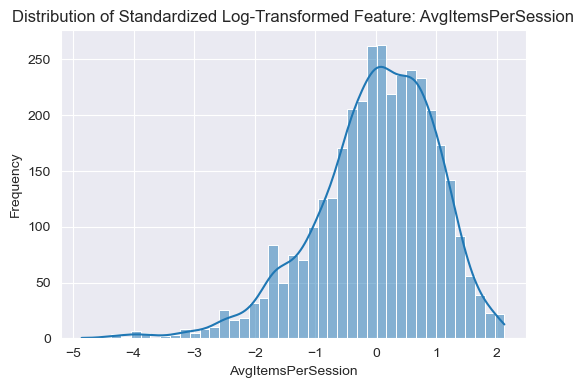

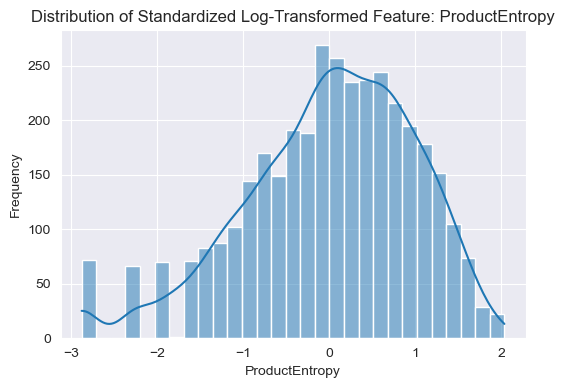

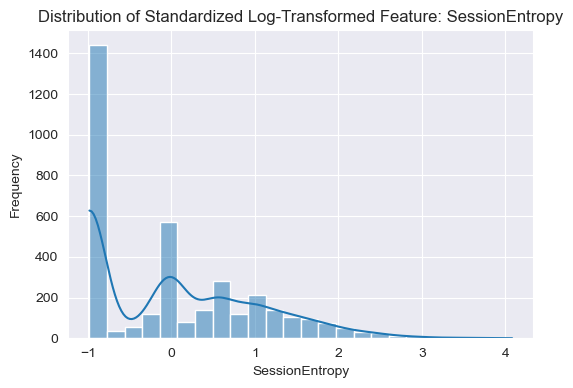

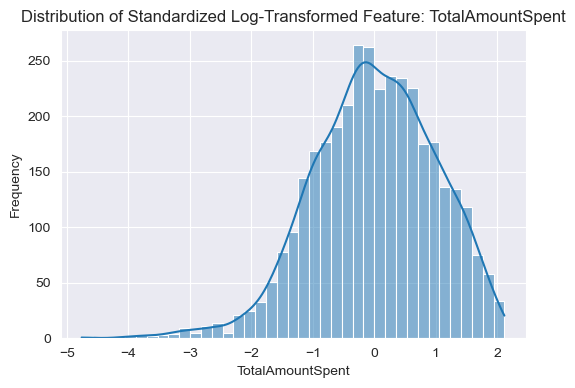

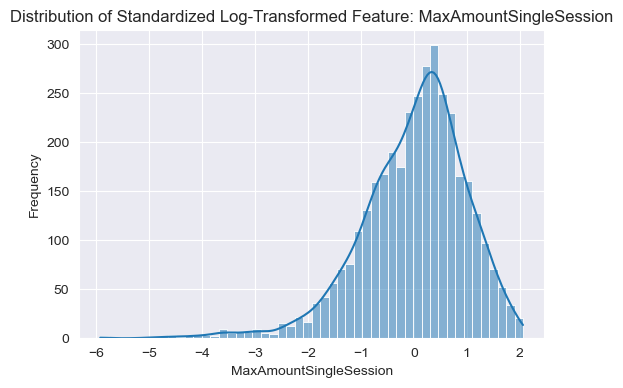

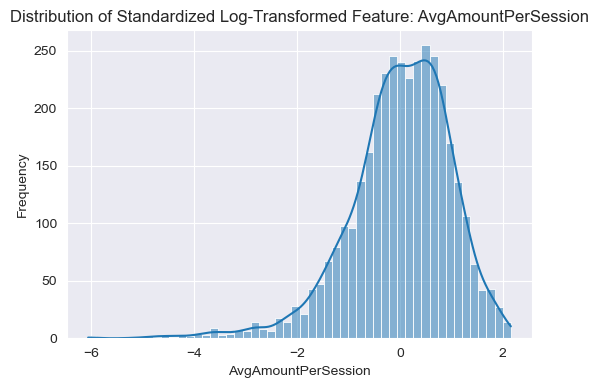

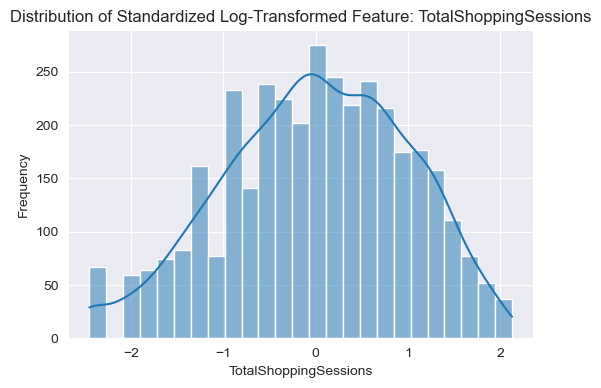

In [6]:
# Visualizing the distributions of the standardized log-transformed features
for column in standardized_data.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(standardized_data[column], kde=True)
    plt.title(f"Distribution of Standardized Log-Transformed Feature: {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()


#### Why Z-Score Normalization Is Used

1. **Z-Score Normalization**:

   - Transforms features to have a **mean of 0** and **standard deviation of 1**.
   - Ensures all features contribute equally to distance or variance calculations.

2. **Comparison with Min-Max Scaling**:

   - Min-Max Scaling rescales features to a fixed range (e.g., [0, 1]).
   - It is sensitive to outliers, making it less ideal for k-means and PCA.
   - Z-Score Normalization is more robust in handling outliers, ensuring better results for distance-based and variance-sensitive algorithms.

# Classification Techniques

In [15]:
data = pd.concat([numerical_data, categorical_data], axis=1)
# Verify combined dataset
print(f"Combined Dataset Shape: {data.shape}")
data.head()

Combined Dataset Shape: (3607, 13)


,TotalItemsPurchased,DistinctItemsPurchased,MaxItemsSingleSession,AvgItemsPerSession,ProductEntropy,SessionEntropy,TotalAmountSpent,MaxAmountSingleSession,AvgAmountPerSession,TotalShoppingSessions,Country,Fav_Weekday,Fav_Month
CustomerID,,,,,,,,,,,,,
17809.0,313,28,204,62.600000,4.807355,1.742063,741.05,560.40,148.210000,28,United Kingdom,Friday,February
16098.0,435,24,112,62.142857,4.305245,2.728077,1107.51,293.14,158.215714,54,United Kingdom,Monday,April
18074.0,52,8,52,52.000000,3.000000,0.000000,185.30,185.30,185.300000,8,United Kingdom,Tuesday,January
17420.0,256,23,112,85.333333,4.483856,1.498689,485.08,215.76,161.693333,25,United Kingdom,Thursday,January
16250.0,206,21,106,103.000000,4.349649,0.987693,373.54,210.24,186.770000,23,United Kingdom,Tuesday,January


In [16]:
# Discretize categorical features
def discretize_data(dataset, variables):
    for variable in variables:
        mapping = dict(zip(sorted(dataset[variable].unique()), range(len(dataset[variable].unique()))))
        dataset[variable + '_num'] = dataset[variable].map(mapping).astype(int)
    return dataset

categorical_vars = ['Country', 'Fav_Weekday', 'Fav_Month']
data = discretize_data(data, categorical_vars)

# Drop original categorical columns
data.drop(columns=categorical_vars, inplace=True)

# Verify transformations
data.info()

<class 'pandas.core.frame.DataFrame'>
Float64Index: 3607 entries, 17809.0 to 12713.0
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TotalItemsPurchased     3607 non-null   int64  
 1   DistinctItemsPurchased  3607 non-null   int64  
 2   MaxItemsSingleSession   3607 non-null   int64  
 3   AvgItemsPerSession      3607 non-null   float64
 4   ProductEntropy          3607 non-null   float64
 5   SessionEntropy          3607 non-null   float64
 6   TotalAmountSpent        3607 non-null   float64
 7   MaxAmountSingleSession  3607 non-null   float64
 8   AvgAmountPerSession     3607 non-null   float64
 9   TotalShoppingSessions   3607 non-null   int64  
 10  Country_num             3607 non-null   int32  
 11  Fav_Weekday_num         3607 non-null   int32  
 12  Fav_Month_num           3607 non-null   int32  
dtypes: float64(6), int32(3), int64(4)
memory usage: 352.2 KB


**Observation**:
- Categorical variables (`Country`, `Fav_Weekday`, `Fav_Month`) are converted into numerical representations.
- Original categorical columns are dropped to avoid redundancy.

### Define Labels

In [17]:
# Define labels based on spending (AvgAmountPerSession)
quantile_a = data['AvgAmountPerSession'].quantile(0.33)
quantile_b = data['AvgAmountPerSession'].quantile(0.66)

labels = []
for value in data['AvgAmountPerSession']:
    if value < quantile_a:
        labels.append(0)  # Low-spending
    elif value > quantile_b:
        labels.append(2)  # High-spending
    else:
        labels.append(1)  # Medium-spending

data['Labels'] = labels
data.drop(columns=['AvgAmountPerSession'], inplace=True)

# Verify label distribution
print(data['Labels'].value_counts())

2    1227
1    1190
0    1190
Name: Labels, dtype: int64


**Observation**:
- Labels (`low`, `medium`, `high` spending) are created based on the 33rd and 66th percentiles of `AvgAmountPerSession`.
- Labels are added as a new column, and the original `AvgAmountPerSession` column is dropped.

###  Train-Test Split

In [18]:
# Split data into train and test sets
X = data.drop(columns=['Labels'])
y = data['Labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")

Train Set Shape: (2885, 12)
Test Set Shape: (722, 12)


**Observation**:
- The dataset is split into training (80%) and testing (20%) sets.
- Stratified sampling ensures proportional representation of labels in both sets.


### Standardize Categorical Features

In [19]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify scaling
print("Features standardized successfully.")

Features standardized successfully.


In [20]:
class SoftmaxRegression:
    """
    Multiclass Logistic Regression (Softmax)
    """

    def __init__(self, 
                 learning_rate=0.01, 
                 epochs=500, 
                 l2_reg=0.01, 
                 verbose=False):
        """
        Parameters:
        -----------
        learning_rate : float
            Step size for gradient descent updates.
        epochs : int
            Number of full passes through the training data.
        l2_reg : float
            L2 regularization strength (lambda). 0.01 = no regularization.
        verbose : bool
            If True, print loss at each epoch.
        """
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.l2_reg = l2_reg
        self.verbose = verbose
        self.W = None
        self.b = None

    def _softmax(self, logits):
        """
        Softmax function for multi-class probabilities.
        logits shape = (n_samples, n_classes)
        """
        exp_scores = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    def _initialize_params(self, n_features, n_classes):
        """
        Initialize weights and bias.
        We use small random values for W, and zeros for b.
        """
        limit = 0.01
        self.W = np.random.uniform(-limit, limit, (n_features, n_classes))
        self.b = np.zeros((1, n_classes))

    def _compute_loss_and_grads(self, X, y):
        """
        1) Forward pass
        2) Compute cross-entropy loss + L2 penalty
        3) Compute gradients w.r.t. W, b
        """
        # n_samples x n_features
        n_samples = X.shape[0]

        # Forward pass (logits and softmax)
        logits = X.dot(self.W) + self.b  # shape: (n_samples, n_classes)
        probs = self._softmax(logits)    # shape: (n_samples, n_classes)

        # One-hot encode y for cross-entropy
        # y is shape (n_samples,) with class labels in {0,1,2}
        y_one_hot = np.zeros_like(probs)
        y_one_hot[np.arange(n_samples), y] = 1.0

        # Cross-entropy loss
        # Add a small epsilon inside log to avoid numerical issues
        epsilon = 1e-10
        loss = -np.sum(y_one_hot * np.log(probs + epsilon)) / n_samples

        # Add L2 regularization penalty if l2_reg > 0
        if self.l2_reg > 0.0:
            loss += self.l2_reg * np.sum(self.W**2) / (2 * n_samples)

        # Compute gradients
        # grad of cross-entropy w.r.t. logits is (probs - y_one_hot)
        d_logits = probs - y_one_hot   # shape: (n_samples, n_classes)

        # Grad w.r.t. W
        dW = (1.0 / n_samples) * X.T.dot(d_logits)  
        # Grad w.r.t. b
        db = (1.0 / n_samples) * np.sum(d_logits, axis=0, keepdims=True)

        # Add L2 gradient contribution
        if self.l2_reg > 0.0:
            dW += (self.l2_reg / n_samples) * self.W

        return loss, dW, db

    def fit(self, X, y):
        """
        Train Softmax using Gradient Descent.
        
        X: shape (n_samples, n_features)
        y: shape (n_samples,) with integer labels in {0,1,2}
        """
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Step 1: Initialize parameters
        self._initialize_params(n_features, n_classes)

        # Step 2: Optimization loop
        for epoch in range(self.epochs):
            # Forward & backward pass
            loss, dW, db = self._compute_loss_and_grads(X, y)

            # Parameter update
            self.W -= self.learning_rate * dW
            self.b -= self.learning_rate * db

            # verbose printing of loss
            if self.verbose and epoch % 50 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """
        Predict class labels for input samples.
        """
        logits = X.dot(self.W) + self.b  # (n_samples, n_classes)
        probs = self._softmax(logits)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        """
        Return class probabilities for input samples.
        """
        logits = X.dot(self.W) + self.b
        probs = self._softmax(logits)
        return probs


In [21]:
# 1. Instantiate our logistic regression model
#    Let's add hyperparameters:
model = SoftmaxRegression(
    learning_rate=0.01, 
    epochs=500, 
    l2_reg=0.001,  # You can try 0.01 or 0.1 
    verbose=False
)

# 2. Fit model on training data
model.fit(X_train_scaled, y_train)

# 3. Predict on test set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate with Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Classification Report:
              precision    recall  f1-score   support

         Low       0.65      0.91      0.76       238
      Medium       0.68      0.37      0.48       238
        High       0.83      0.87      0.85       246

    accuracy                           0.72       722
   macro avg       0.72      0.72      0.70       722
weighted avg       0.72      0.72      0.70       722


In [22]:
from sklearn.model_selection import StratifiedKFold


###############################################################################
# 1) Define grid of hyperparameters
param_grid = {
    "learning_rate": [0.001, 0.01],
    "epochs": [500, 1000],
    "l2_reg": [0.0, 0.01],
}

###############################################################################
# 2) Manual Grid Search with K-Fold Cross-Validation
def manual_grid_search_scratch(X, y, param_grid, k=3):
    """
    X, y: training set
    param_grid: dict of lists of hyperparameters
    k: number of folds for cross-validation

    Returns best_params, best_score
    """
    best_score = -np.inf
    best_params = None
    
    # Prepare for Stratified k-fold
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    # Let's generate all combinations of param_grid
    import itertools
    keys = list(param_grid.keys())
    vals = [param_grid[k] for k in keys]  # list of lists
    for combination in itertools.product(*vals):
        # Build param dictionary for this combination
        params = dict(zip(keys, combination))

        # Collect fold accuracies
        fold_accuracies = []

        for train_index, val_index in skf.split(X, y):
            # Split into train/val for this fold
            X_train_fold, X_val_fold = X[train_index], X[val_index]
            y_train_fold, y_val_fold = y[train_index], y[val_index]
            
            # Instantiate and train model
            model = SoftmaxRegression(
                learning_rate=params["learning_rate"],
                epochs=params["epochs"],
                l2_reg=params["l2_reg"],
                verbose=False
            )
            model.fit(X_train_fold, y_train_fold)
            
            # Predict and measure accuracy
            y_val_pred = model.predict(X_val_fold)
            fold_acc = accuracy_score(y_val_fold, y_val_pred)
            fold_accuracies.append(fold_acc)
        
        # Mean accuracy across k folds
        mean_acc = np.mean(fold_accuracies)
        
        # Check if this is the best so far
        if mean_acc > best_score:
            best_score = mean_acc
            best_params = params
    
    return best_params, best_score

###############################################################################
# 3) Run the Grid Search on  Training Data
best_params, best_score = manual_grid_search_scratch(X_train_scaled, y_train.values, param_grid, k=3)
print("Best Hyperparameters found:")
print(best_params)
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")

###############################################################################
# 4) Retrain on the Entire Training Set with Best Hyperparams
best_model = SoftmaxRegression(
    learning_rate=best_params["learning_rate"],
    epochs=best_params["epochs"],
    l2_reg=best_params["l2_reg"],
    verbose=False
)
best_model.fit(X_train_scaled, y_train.values)

###############################################################################
# 5) Evaluate on Test Set
y_pred_test = best_model.predict(X_test_scaled)

print("\nClassification Report with Tuned Hyperparameters:")
print(classification_report(y_test, y_pred_test, target_names=['Low', 'Medium', 'High']))

Best Hyperparameters found:
{'learning_rate': 0.01, 'epochs': 1000, 'l2_reg': 0.0}
Best Cross-Validation Accuracy: 0.7577

Classification Report with Tuned Hyperparameters:
              precision    recall  f1-score   support

         Low       0.73      0.91      0.81       238
      Medium       0.72      0.53      0.61       238
        High       0.86      0.87      0.87       246

    accuracy                           0.77       722
   macro avg       0.77      0.77      0.76       722
weighted avg       0.77      0.77      0.76       722


In [23]:
# metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, average='weighted')
rec = recall_score(y_test, y_pred_test, average='weighted')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

Accuracy:  0.7715
Precision: 0.7700
Recall:    0.7715


In [24]:
def gini_impurity(y):
    """
    Compute Gini Impurity for labels in y.
    """
    classes, counts = np.unique(y, return_counts=True)
    n = len(y)
    impurity = 1.0 - sum((count / n) ** 2 for count in counts)
    return impurity

def entropy_impurity(y):
    """
    Compute Entropy for labels in y.
    H = - sum(p_i * log2(p_i))
    """
    classes, counts = np.unique(y, return_counts=True)
    n = len(y)
    probs = counts / n
    # Add small epsilon to avoid log2(0)
    epsilon = 1e-10
    entropy = -np.sum(probs * np.log2(probs + epsilon))
    return entropy

def compute_impurity(y, criterion='gini'):
    """
    Wrapper to compute either Gini or Entropy based on criterion.
    """
    if criterion == 'gini':
        return gini_impurity(y)
    elif criterion == 'entropy':
        return entropy_impurity(y)
    else:
        raise ValueError("criterion must be 'gini' or 'entropy'")

In [25]:
class Node:
    def __init__(self, feature_index=None, threshold=None,left=None, right=None, value=None):
        """
        If 'value' is not None, it's a leaf node.
        Otherwise, it's an internal node with:
          feature_index: which feature to split on
          threshold: the numeric threshold
          left: Node
          right: Node
        """
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # for leaf nodes

def split_dataset(X, y, feature_index, threshold):
    """
    Split dataset into left/right arrays based on 'threshold' for a chosen feature.
    """
    left_mask = X[:, feature_index] <= threshold
    right_mask = ~left_mask
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]


In [26]:
def best_split(X, y, criterion='gini'):
    """
    Return (best_feature_index, best_threshold, best_gain).
    If no split improves purity, returns (None, None, None).
    """
    n_samples, n_features = X.shape
    if n_samples <= 1:
        return None, None, None

    parent_impurity = compute_impurity(y, criterion)
    best_gain = 0.0
    best_feature = None
    best_thresh = None

    for feature_index in range(n_features):
        # For each unique value in this feature
        thresholds = np.unique(X[:, feature_index])
        for thresh in thresholds:
            X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, thresh)
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            # Weighted child impurity
            n_left, n_right = len(y_left), len(y_right)
            n_total = n_left + n_right

            left_imp = compute_impurity(y_left, criterion)
            right_imp = compute_impurity(y_right, criterion)
            child_impurity = (n_left/n_total)*left_imp + (n_right/n_total)*right_imp

            # Information Gain = parent_impurity - child_impurity
            gain = parent_impurity - child_impurity
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_index
                best_thresh = thresh

    if best_gain <= 0:
        return None, None, None
    return best_feature, best_thresh, best_gain


In [27]:
class DecisionTreeScratch:
    def __init__(self, max_depth=None, min_samples_split=2, criterion='gini', random_state=None):
        """
        max_depth: int or None
        min_samples_split: int
        criterion: 'gini' or 'entropy'
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.random_state = random_state
        self.root = None

    def _majority_class(self, y):
        """Return the most frequent class in y."""
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def _build_tree(self, X, y, depth=0):
        # If all labels are same -> leaf node
        if len(np.unique(y)) == 1:
            return Node(value=y[0])

        # If we exceed max_depth
        if (self.max_depth is not None) and (depth >= self.max_depth):
            leaf_value = self._majority_class(y)
            return Node(value=leaf_value)

        # If not enough samples to split
        if len(y) < self.min_samples_split:
            leaf_value = self._majority_class(y)
            return Node(value=leaf_value)

        # Find best split
        feature_index, threshold, gain = best_split(X, y, self.criterion)
        if feature_index is None or gain is None:
            # No improvement => leaf
            leaf_value = self._majority_class(y)
            return Node(value=leaf_value)

        X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, threshold)

        # Build subtrees
        left_child = self._build_tree(X_left, y_left, depth+1)
        right_child = self._build_tree(X_right, y_right, depth+1)

        # Internal node
        return Node(feature_index=feature_index, threshold=threshold,
                    left=left_child, right=right_child)

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _predict_sample(self, x, node):
        # If leaf
        if node.value is not None:
            return node.value
        # Traverse left or right
        if x[node.feature_index] <= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)

    def predict(self, X):
        return np.array([self._predict_sample(x, self.root) for x in X])


In [28]:
from sklearn.model_selection import StratifiedKFold

def manual_grid_search_decision_tree(X, y, param_grid, k=3):
    """
    param_grid example:
      {
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 5],
        'min_samples_split': [2, 5]
      }
    """
    import itertools

    best_score = -np.inf
    best_params = None
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    keys = list(param_grid.keys())
    vals = [param_grid[k] for k in keys]

    for combination in itertools.product(*vals):
        params = dict(zip(keys, combination))
        fold_accuracies = []

        for train_idx, val_idx in skf.split(X, y):
            X_train_fold, X_val_fold = X[train_idx], X[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]

            # Create tree
            tree_model = DecisionTreeScratch(
                criterion=params.get('criterion', 'gini'),
                max_depth=params.get('max_depth', None),
                min_samples_split=params.get('min_samples_split', 2)
            )
            tree_model.fit(X_train_fold, y_train_fold)

            y_val_pred = tree_model.predict(X_val_fold)
            fold_accuracies.append(accuracy_score(y_val_fold, y_val_pred))

        mean_acc = np.mean(fold_accuracies)
        if mean_acc > best_score:
            best_score = mean_acc
            best_params = params

    return best_params, best_score


In [29]:
# Example parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

best_params_dt, best_score_dt = manual_grid_search_decision_tree(
    X_train_scaled, y_train.values, param_grid, k=3
)

print("Best Decision Tree Hyperparameters:")
print(best_params_dt)
print(f"Best CV score: {best_score_dt:.4f}")

# Retrain on entire training set with best hyperparams
best_tree_model = DecisionTreeScratch(
    criterion=best_params_dt['criterion'],
    max_depth=best_params_dt['max_depth'],
    min_samples_split=best_params_dt['min_samples_split']
)
best_tree_model.fit(X_train_scaled, y_train.values)

# Evaluate
y_pred_tree = best_tree_model.predict(X_test_scaled)
print("\nDecision Tree (Entropy/Gini) Classification Report:")
print(classification_report(y_test, y_pred_tree, target_names=['Low','Medium','High']))

acc_dt = accuracy_score(y_test, y_pred_tree)
prec_dt = precision_score(y_test, y_pred_tree, average='weighted')
rec_dt = recall_score(y_test, y_pred_tree, average='weighted')
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")


Best Decision Tree Hyperparameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best CV score: 0.9071

Decision Tree (Entropy/Gini) Classification Report:
              precision    recall  f1-score   support

         Low       0.97      0.97      0.97       238
      Medium       0.89      0.90      0.90       238
        High       0.93      0.92      0.93       246

    accuracy                           0.93       722
   macro avg       0.93      0.93      0.93       722
weighted avg       0.93      0.93      0.93       722

Accuracy:  0.9307
Precision: 0.9311
Recall:    0.9307


# Naive Bayes from Scratch (Gaussian NB)

Now let’s move on to a **Naive Bayes** classifier from scratch, specifically the **Gaussian** variant (assuming your features are numeric and roughly follow a normal distribution).

## 1. Theory in Brief

Gaussian Naive Bayes assumes each feature $\( X_j \)$ is conditionally independent given the class $\( c \)$, and follows a normal distribution with some $\(\mu_{j,c}\)$ and $\(\sigma_{j,c}^2\)$. The posterior is:


We pick the class $ \( \hat{c} \) $ that maximizes this posterior.



In [30]:
class GaussianNaiveBayesScratch:
    def __init__(self):
        """
        We'll store:
        - class_prior_ : dict of {class_label: prior_probability}
        - means_ : dict of {class_label: array of feature means}
        - vars_ : dict of {class_label: array of feature variances}
        """
        self.class_prior_ = {}
        self.means_ = {}
        self.vars_ = {}
        self.classes_ = None

    def fit(self, X, y):
        """
        X: (n_samples, n_features)
        y: (n_samples,)
        """
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        for c in self.classes_:
            # Extract samples for this class
            X_c = X[y == c]
            # Prior = P(class) = count(class) / total
            self.class_prior_[c] = len(X_c) / n_samples
            # Mean and variance for each feature
            self.means_[c] = np.mean(X_c, axis=0)
            self.vars_[c] = np.var(X_c, axis=0) + 1e-9  # add small epsilon to avoid /0

    def _gaussian_pdf(self, x, mean, var):
        """
        Probability density of x under N(mean, var).
        x, mean, var are scalars or vectors with same shape.
        For multiple features, compute elementwise then product.
        We'll return the log-prob to prevent underflow.
        """
        # log(1 / sqrt(2*pi*var)) = -0.5 * log(2*pi*var)
        # - (x-mean)^2 / (2*var)
        eps = 1e-9
        return -0.5 * np.log(2.0 * np.pi * var + eps) - ((x - mean) ** 2) / (2 * var + eps)

    def predict(self, X):
        """
        Compute posterior for each class = log prior + sum of log-likelihoods (Gaussian).
        Choose class with highest posterior.
        """
        n_samples, n_features = X.shape
        y_pred = []

        for i in range(n_samples):
            posteriors = []
            for c in self.classes_:
                # log P(c)
                log_prior = np.log(self.class_prior_[c])
                # sum of log Gaussian PDFs for each feature
                mean_c = self.means_[c]
                var_c = self.vars_[c]
                log_likelihood = np.sum(self._gaussian_pdf(X[i], mean_c, var_c))
                # posterior ~ log_prior + log_likelihood
                posterior = log_prior + log_likelihood
                posteriors.append((c, posterior))
            # pick class with largest posterior
            best_class = max(posteriors, key=lambda x: x[1])[0]
            y_pred.append(best_class)

        return np.array(y_pred)


In [31]:
# Instantiate and fit
nb_scratch = GaussianNaiveBayesScratch()
nb_scratch.fit(X_train_scaled, y_train.values)

# Predict on test
y_pred_nb = nb_scratch.predict(X_test_scaled)

# Evaluate
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

print("Naive Bayes from Scratch - Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Low','Medium','High']))

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy:  {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall:    {rec_nb:.4f}")


Naive Bayes from Scratch - Classification Report:
              precision    recall  f1-score   support

         Low       0.69      0.89      0.78       238
      Medium       0.56      0.53      0.54       238
        High       0.86      0.67      0.76       246

    accuracy                           0.70       722
   macro avg       0.70      0.70      0.69       722
weighted avg       0.71      0.70      0.69       722

Accuracy:  0.6953
Precision: 0.7062
Recall:    0.6953


In [32]:


class KNNClassifierScratch:
    def __init__(self, k=3, distance_metric='euclidean'):
        """
        k: number of nearest neighbors to consider
        distance_metric: 'euclidean' or 'manhattan', etc.
        """
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Simply store the training data. KNN is a lazy learner.
        """
        self.X_train = X
        self.y_train = y

    def _distance(self, x1, x2):
        """
        Compute the distance between x1 and x2 based on self.distance_metric.
        x1, x2: 1D numpy arrays.
        """
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Unsupported distance metric.")

    def predict(self, X):
        """
        For each sample in X, find the k nearest neighbors in the training set.
        Return the majority class label.
        """
        predictions = []
        for x in X:
            # 1) Compute distances from x to all training samples
            distances = []
            for i, x_train in enumerate(self.X_train):
                dist = self._distance(x, x_train)
                distances.append((dist, self.y_train[i]))

            # 2) Sort by distance
            distances.sort(key=lambda d: d[0])
            # 3) Take top k
            k_neighbors = distances[:self.k]
            # 4) Majority vote
            neighbor_labels = [label for (dist, label) in k_neighbors]
            most_common_label = Counter(neighbor_labels).most_common(1)[0][0]
            predictions.append(most_common_label)

        return np.array(predictions)


In [33]:
class KNNClassifierScratch:
    def __init__(self, k=3, distance_metric='euclidean', p=2):
        """
        k: number of neighbors
        distance_metric: 'euclidean', 'manhattan', 'chebyshev', 'minkowski'
        p: exponent for Minkowski if distance_metric='minkowski'
        """
        self.k = k
        self.distance_metric = distance_metric
        self.p = p
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Store the training data as NumPy arrays.
        """
        # Convert to NumPy if they're pandas objects
        if not isinstance(X, np.ndarray):
            X = X.values  # if X is a DataFrame
        if not isinstance(y, np.ndarray):
            y = y.values  # if y is a Series

        self.X_train = X
        self.y_train = y

    def _distance(self, x1, x2):
        """
        Compute distance based on self.distance_metric.
        """
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2)**2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        elif self.distance_metric == 'chebyshev':
            return np.max(np.abs(x1 - x2))
        elif self.distance_metric == 'minkowski':
            return (np.sum(np.abs(x1 - x2)**self.p)) ** (1.0/self.p)
        else:
            raise ValueError("Unsupported or unknown distance metric.")

    def predict(self, X):
        """
        For each sample in X, find k nearest neighbors and do a majority vote.
        """
        # Convert to NumPy if needed
        if not isinstance(X, np.ndarray):
            X = X.values

        predictions = []
        for x in X:
            # Compute distances from x to all training points
            distances = []
            for i, x_train in enumerate(self.X_train):
                dist = self._distance(x, x_train)
                # Append tuple: (distance, class_label)
                distances.append((dist, self.y_train[i]))
            # Sort by distance
            distances.sort(key=lambda d: d[0])
            # Take top k
            k_neighbors = distances[:self.k]
            # Majority vote
            neighbor_labels = [label for (dist, label) in k_neighbors]
            most_common_label = Counter(neighbor_labels).most_common(1)[0][0]
            predictions.append(most_common_label)

        return np.array(predictions)

In [34]:
X_train_arr = X_train_scaled
y_train_arr = y_train
X_test_arr  = X_test_scaled


# Define the list of metrics you want to test
distance_metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']

# We can keep 'k=5' for all, and we'll do 'p=3' for Minkowski specifically,
# but if the metric is not 'minkowski', 'p' will just be ignored.
for metric in distance_metrics:
    knn_model = KNNClassifierScratch(k=5, distance_metric=metric, p=3)
    knn_model.fit(X_train_arr, y_train_arr)
    y_pred = knn_model.predict(X_test_arr)

    print(f"\nKNN with distance_metric='{metric}':")
    # If Minkowski is chosen and we used p=3, mention that:
    if metric == 'minkowski':
        print("   (Using p=3)")

    # Print classification results
    print(classification_report(y_test, y_pred))
    acc = accuracy_score(y_test, y_pred)
    print(f"   Accuracy ({metric}): {acc:.4f}")


KNN with distance_metric='euclidean':
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       238
           1       0.75      0.78      0.76       238
           2       0.91      0.87      0.89       246

    accuracy                           0.84       722
   macro avg       0.84      0.84      0.84       722
weighted avg       0.84      0.84      0.84       722

   Accuracy (euclidean): 0.8421

KNN with distance_metric='manhattan':
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       238
           1       0.74      0.78      0.76       238
           2       0.90      0.86      0.88       246

    accuracy                           0.84       722
   macro avg       0.84      0.84      0.84       722
weighted avg       0.84      0.84      0.84       722

   Accuracy (manhattan): 0.8380

KNN with distance_metric='chebyshev':
              precision    recall  f1-score   support

  

## 1. **Softmax Regression (Logistic Regression with Multiclass Softmax)**

1. **Initial Baseline**  
   - Accuracy around **72%** with default hyperparameters.  
   - Class imbalance in `Medium` class might cause lower recall for that class.

2. **Hyperparameter Tuning**  
   - Through **manual grid search** (learning_rate, epochs, l2_reg) + 3-fold cross-validation, we found:
     $$ \[
       \text{best\_params} = \{\text{learning\_rate}=0.01,\; \text{epochs}=1000,\; \text{l2\_reg}=0.0\}
     \] $$
   - This **improved accuracy** to about **77%** on the test set, with better precision/recall balance.

3. **Interpretation**  
   - Logistic regression can handle **linear** decision boundaries.  
   - For class boundaries that are more complex or non-linear, performance may be not the best suite.  

---

## 2. **Decision Tree (from Scratch)**

1. **Hyperparameter Tuning**  
   - By searching over `(criterion, max_depth, min_samples_split)`, we found:
     $$ \[
       \text{best\_params} = \{\text{criterion}='entropy',\; \text{max\_depth}=\text{None},\; \text{min\_samples\_split}=2\}
     \] $$
   - This gave a **CV accuracy** of ~**90.71%** and a **test accuracy** of ~**93.07%**, which is quite high.

2. **Interpretation**  
   - Decision trees **capture non-linear** relationships well.  
---

## 3. **Naive Bayes (Gaussian)**

1. **Baseline Performance**  
   - Accuracy ~ **69.53%** on the test set (f1-scores in the mid 70s range for some classes).  
   - Does quite well on `Low`-spending class (89% recall), but lower performance for `Medium` or `High`.

2. **Data Assumptions**  
   - Naive Bayes (Gaussian) assumes **normal distributions** for each feature **conditional** on the class, plus **feature independence**.  


---

## 4. **K-Nearest Neighbors (KNN)**

We tested **k=5** neighbors with four distance metrics: **Euclidean, Manhattan, Chebyshev, Minkowski** (p=3).

1. **Accuracy Results**  
   - **Euclidean**: ~**84.21%**  
   - **Manhattan**: ~**83.80%**  
   - **Chebyshev**: ~**79.78%**  
   - **Minkowski** (p=3): ~**81.99%**

2. **Observations**  
   - KNN yields strong performance (84% with Euclidean), **competitive** with logistic regression.  

3. **Interpretation**  
   - KNN is **simple** but can be **sensitive** to outliers or high-dimensional data.  
   - Tuning both **k** and **distance metric** is critical.  

---

## 5. **Overall Findings and Suggestions**

1. **Best Performance**  
   - **Decision Tree**  gave the **highest** test accuracy (~93%), indicating the data may have strong patterns that a deep tree can exploit.

2. **Second Tier**  
   - **KNN** with Euclidean distance (~84%),  
   - **Softmax Regression** after tuning (~77%),  
   - **Naive Bayes** (~70%).